# Air Quality Analytics Report

This notebook summarizes the curated Sofia AQI dataset using the shared Spark batch analytics pipeline in `src/analytics/`.

It loads the report tables once, converts them to pandas for presentation, and closes the Spark session automatically.

## Source and Report Scope

Curated source path:

`hdfs://namenode:9000/data/air-quality/sofia/curated/*.jsonl`

Report tables included in this notebook:

- `hourly_aqi`
- `daily_aqi`
- `aqi_category_distribution`
- `average_pollutants`
- `dominant_pollutants`
- `weather_correlations`

In [1]:
from IPython.display import display
from matplotlib import pyplot as plt

from src.analytics.batch_analysis import DEFAULT_CITY
from src.analytics.batch_analysis import DEFAULT_HDFS_ROOT
from src.analytics.batch_analysis import create_spark_session
from src.analytics.batch_analysis import run_batch_analysis
from src.analytics.batch_analysis import to_pandas_table

plt.style.use("seaborn-v0_8-whitegrid")


def load_report_tables():
    spark = create_spark_session("air-quality-analytics-notebook")
    try:
        results = run_batch_analysis(spark, DEFAULT_HDFS_ROOT, DEFAULT_CITY)
        normalized = results["normalized"]
        return {
            "normalized_schema": normalized._jdf.schema().treeString(),
            "normalized_count": normalized.count(),
            "normalized_preview": to_pandas_table(
                normalized.select(
                    "timestamp",
                    "event_timestamp",
                    "day",
                    "hour",
                    "aqi",
                    "dominant_pollutant",
                ).limit(5)
            ),
            "hourly_aqi": to_pandas_table(results["hourly_aqi"]),
            "daily_aqi": to_pandas_table(results["daily_aqi"]),
            "aqi_category_distribution": to_pandas_table(results["aqi_category_distribution"]),
            "average_pollutants": to_pandas_table(results["average_pollutants"]),
            "dominant_pollutants": to_pandas_table(results["dominant_pollutants"]),
            "weather_correlations": to_pandas_table(results["weather_correlations"]),
        }
    finally:
        spark.stop()


report_tables = load_report_tables()
sorted(report_tables)

['aqi_category_distribution',
 'average_pollutants',
 'daily_aqi',
 'dominant_pollutants',
 'hourly_aqi',
 'normalized_count',
 'normalized_preview',
 'normalized_schema',
 'weather_correlations']

## Dataset Snapshot

In [2]:
print(report_tables["normalized_schema"])
print(f"Normalized records included in analytics: {report_tables['normalized_count']}")
display(report_tables["normalized_preview"])

root
 |-- timestamp: string (nullable = true)
 |-- station_id: integer (nullable = true)
 |-- station_name: string (nullable = true)
 |-- latitude: double (nullable = true)
 |-- longitude: double (nullable = true)
 |-- aqi: integer (nullable = true)
 |-- dominant_pollutant: string (nullable = true)
 |-- pm10: double (nullable = true)
 |-- no2: double (nullable = true)
 |-- o3: double (nullable = true)
 |-- temperature: double (nullable = true)
 |-- humidity: double (nullable = true)
 |-- wind: double (nullable = true)
 |-- pressure: double (nullable = true)
 |-- dew: double (nullable = true)
 |-- event_timestamp: timestamp (nullable = true)
 |-- day: string (nullable = true)
 |-- hour: integer (nullable = true)

Normalized records included in analytics: 108


,timestamp,event_timestamp,day,hour,aqi,dominant_pollutant
0,2026-04-10T18:00:00+03:00,2026-04-10 15:00:00,2026-04-10,15,42,o3
1,2026-04-10T18:00:00+03:00,2026-04-10 15:00:00,2026-04-10,15,42,o3
2,2026-04-10T18:00:00+03:00,2026-04-10 15:00:00,2026-04-10,15,42,o3
3,2026-04-10T18:00:00+03:00,2026-04-10 15:00:00,2026-04-10,15,42,o3
4,2026-04-10T18:00:00+03:00,2026-04-10 15:00:00,2026-04-10,15,42,o3


## AQI Trends

In [3]:
hourly_pdf = report_tables["hourly_aqi"]
display(hourly_pdf)

,hour,avg_aqi
0,13,35.0
1,15,42.0
2,16,37.0
3,17,30.0


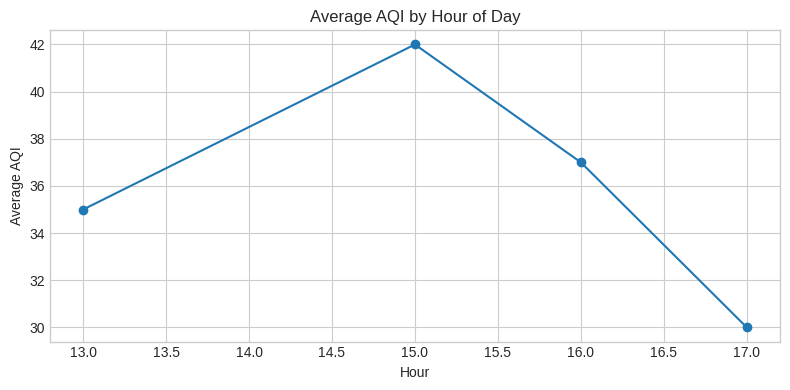

In [4]:
ax = hourly_pdf.plot(kind="line", x="hour", y="avg_aqi", marker="o", legend=False, figsize=(8, 4))
ax.set_title("Average AQI by Hour of Day")
ax.set_xlabel("Hour")
ax.set_ylabel("Average AQI")
plt.tight_layout()
plt.show()

In [5]:
daily_pdf = report_tables["daily_aqi"]
display(daily_pdf)

,day,avg_aqi
0,2026-04-10,37.172043
1,2026-04-11,35.000000


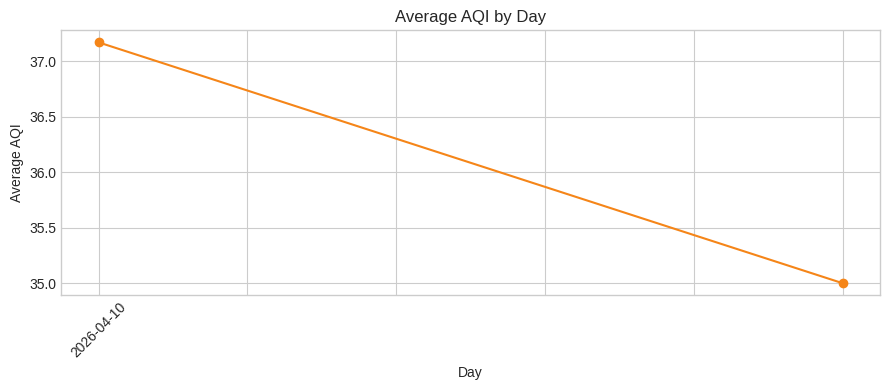

In [6]:
ax = daily_pdf.plot(kind="line", x="day", y="avg_aqi", marker="o", legend=False, figsize=(9, 4), color="#f58518")
ax.set_title("Average AQI by Day")
ax.set_xlabel("Day")
ax.set_ylabel("Average AQI")
ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## AQI Category Distribution

In [7]:
aqi_category_pdf = report_tables["aqi_category_distribution"]
display(aqi_category_pdf)

,aqi_category,count
0,Good,108


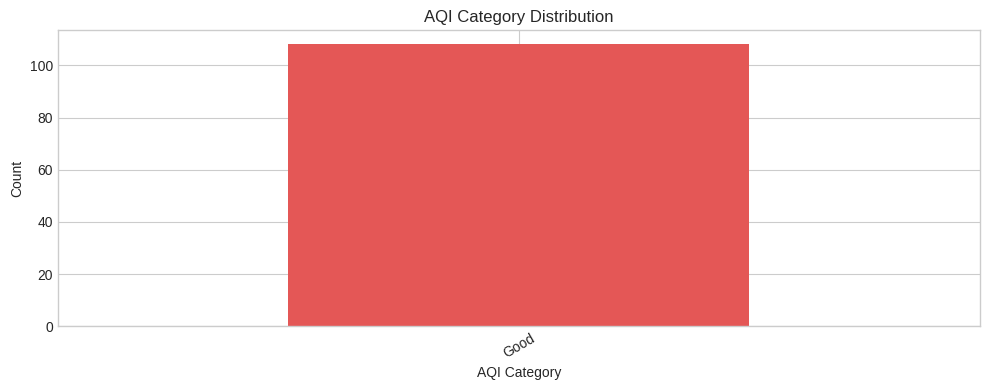

In [8]:
ax = aqi_category_pdf.plot(kind="bar", x="aqi_category", y="count", legend=False, figsize=(10, 4), color="#e45756")
ax.set_title("AQI Category Distribution")
ax.set_xlabel("AQI Category")
ax.set_ylabel("Count")
ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

## Pollutant Profile

In [9]:
pollutants_pdf = report_tables["average_pollutants"]
display(pollutants_pdf)

,avg_pm10,avg_no2,avg_o3
0,9.962963,6.342593,36.868519


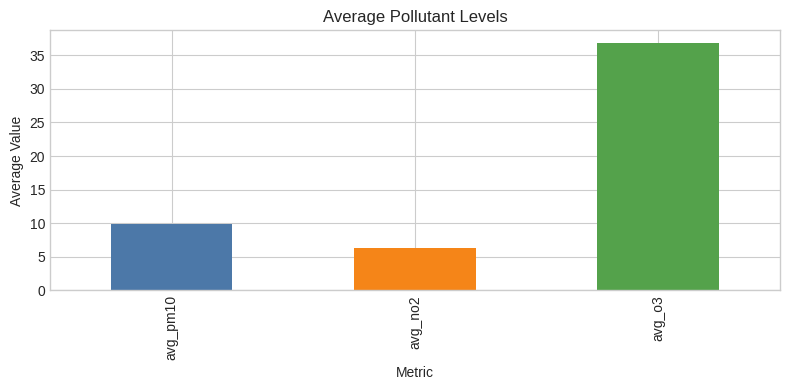

In [10]:
pollutant_values = pollutants_pdf.iloc[0][["avg_pm10", "avg_no2", "avg_o3"]]
ax = pollutant_values.plot(kind="bar", figsize=(8, 4), color=["#4c78a8", "#f58518", "#54a24b"])
ax.set_title("Average Pollutant Levels")
ax.set_xlabel("Metric")
ax.set_ylabel("Average Value")
plt.tight_layout()
plt.show()

## Dominant Pollutants

In [11]:
dominant_pdf = report_tables["dominant_pollutants"]
display(dominant_pdf)

,dominant_pollutant,count
0,o3,108


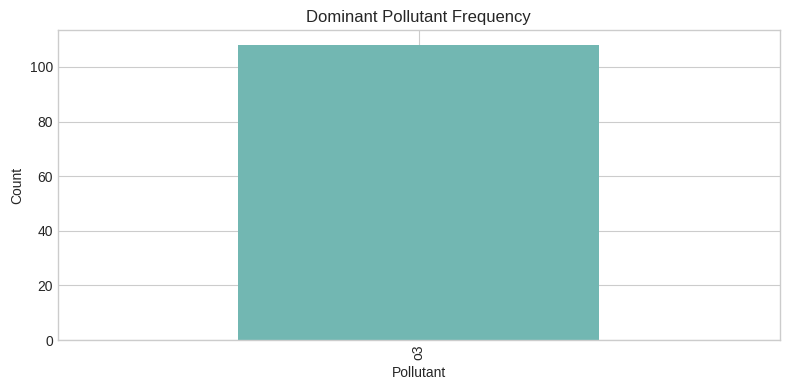

In [12]:
ax = dominant_pdf.plot(kind="bar", x="dominant_pollutant", y="count", legend=False, figsize=(8, 4), color="#72b7b2")
ax.set_title("Dominant Pollutant Frequency")
ax.set_xlabel("Pollutant")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

## Weather Relationships

In [13]:
correlations_pdf = report_tables["weather_correlations"]
display(correlations_pdf)

,aqi_temperature_corr,aqi_humidity_corr,aqi_wind_corr
0,0.861402,-0.297235,0.745624


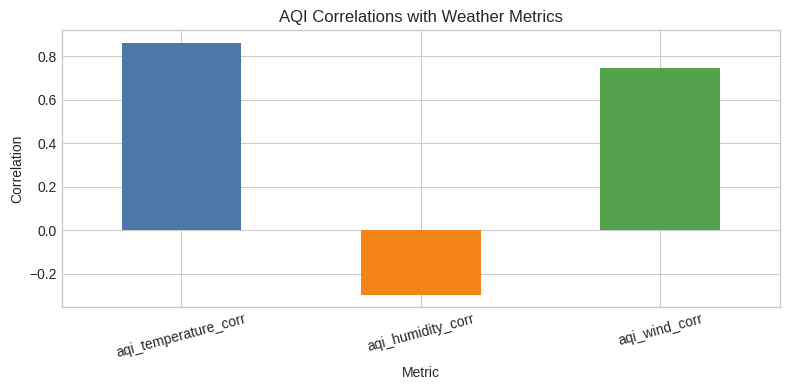

In [14]:
correlation_values = correlations_pdf.iloc[0]
ax = correlation_values.plot(kind="bar", figsize=(8, 4), color=["#4c78a8", "#f58518", "#54a24b"])
ax.set_title("AQI Correlations with Weather Metrics")
ax.set_xlabel("Metric")
ax.set_ylabel("Correlation")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

## Summary

In [15]:
peak_hour = hourly_pdf.loc[hourly_pdf["avg_aqi"].idxmax()]
peak_day = daily_pdf.loc[daily_pdf["avg_aqi"].idxmax()]
top_category = aqi_category_pdf.iloc[0]
top_pollutant = dominant_pdf.iloc[0]
correlation_values = correlations_pdf.iloc[0].dropna()
strongest_metric = correlation_values.abs().idxmax()

print(f"- Highest average hourly AQI: {peak_hour['avg_aqi']:.1f} at hour {int(peak_hour['hour'])}.")
print(f"- Highest average daily AQI: {peak_day['avg_aqi']:.1f} on {peak_day['day']}.")
print(f"- Most common AQI category: {top_category['aqi_category']} ({int(top_category['count'])} records).")
print(f"- Most common dominant pollutant: {top_pollutant['dominant_pollutant']} ({int(top_pollutant['count'])} records).")
print(
    f"- Strongest AQI-weather relationship by absolute correlation: {strongest_metric} = {correlation_values[strongest_metric]:.3f}."
)

- Highest average hourly AQI: 42.0 at hour 15.
- Highest average daily AQI: 37.2 on 2026-04-10.
- Most common AQI category: Good (108 records).
- Most common dominant pollutant: o3 (108 records).
- Strongest AQI-weather relationship by absolute correlation: aqi_temperature_corr = 0.861.
